#K-Means Clustering (Unsupervised Learning)

In [2]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import pandas as pd

##Load dataset

In [3]:
iris = load_iris()

In [4]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [5]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

##Convert to dataframe

In [6]:
df = pd.DataFrame(iris.data)
df

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


##Let's use two columns

In [7]:
df = df.drop([0,1],axis='columns')

In [8]:
df

,2,3
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


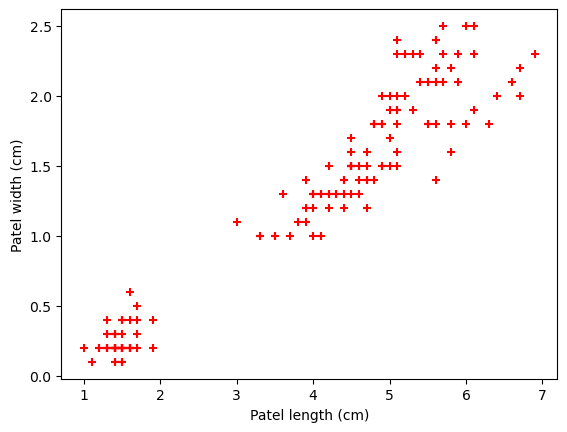

In [9]:
plt.scatter(df[2], df[3] , color = 'red', marker = '+')
plt.xlabel('Patel length (cm)')
plt.ylabel('Patel width (cm)')
plt.show()

## 🔬 Scale a Single Feature Using MinMaxScaler

In this step, we apply `MinMaxScaler` to scale a specific feature of the dataset.

### 🧮 Why MinMaxScaler?
- It scales values **between 0 and 1** (or a custom range).
- Useful for algorithms that are sensitive to feature magnitude (e.g., KMeans, SVM, Neural Networks).


In [10]:
s_length = MinMaxScaler()
s_length.fit(df[[2]])
df[2] = s_length.transform(df[[2]])

df

,2,3
0,0.067797,0.2
1,0.067797,0.2
2,0.050847,0.2
3,0.084746,0.2
4,0.067797,0.2
...,...,...
145,0.711864,2.3
146,0.677966,1.9
147,0.711864,2.0
148,0.745763,2.3


In [11]:
s_width = MinMaxScaler()
s_width.fit(df[[3]])
df[3] = s_width.transform(df[[3]])

df

,2,3
0,0.067797,0.041667
1,0.067797,0.041667
2,0.050847,0.041667
3,0.084746,0.041667
4,0.067797,0.041667
...,...,...
145,0.711864,0.916667
146,0.677966,0.750000
147,0.711864,0.791667
148,0.745763,0.916667


In [12]:
model = KMeans(n_clusters=2)
y_predicted = model.fit_predict(df[[2,3]])

y_predicted

d:\Miniconda\envs\ai-bootcamp\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [13]:
df['predicted'] = y_predicted

df

,2,3,predicted
0,0.067797,0.041667,1
1,0.067797,0.041667,1
2,0.050847,0.041667,1
3,0.084746,0.041667,1
4,0.067797,0.041667,1
...,...,...,...
145,0.711864,0.916667,0
146,0.677966,0.750000,0
147,0.711864,0.791667,0
148,0.745763,0.916667,0


In [14]:
df1 = df[df['predicted']==0]
df2 = df[df['predicted']==1]

print(df1)
print(df2)

            2         3  predicted
50   0.627119  0.541667          0
51   0.593220  0.583333          0
52   0.661017  0.583333          0
53   0.508475  0.500000          0
54   0.610169  0.583333          0
..        ...       ...        ...
145  0.711864  0.916667          0
146  0.677966  0.750000          0
147  0.711864  0.791667          0
148  0.745763  0.916667          0
149  0.694915  0.708333          0

[100 rows x 3 columns]
           2         3  predicted
0   0.067797  0.041667          1
1   0.067797  0.041667          1
2   0.050847  0.041667          1
3   0.084746  0.041667          1
4   0.067797  0.041667          1
5   0.118644  0.125000          1
6   0.067797  0.083333          1
7   0.084746  0.041667          1
8   0.067797  0.041667          1
9   0.084746  0.000000          1
10  0.084746  0.041667          1
11  0.101695  0.041667          1
12  0.067797  0.000000          1
13  0.016949  0.000000          1
14  0.033898  0.041667          1
15  0.084746

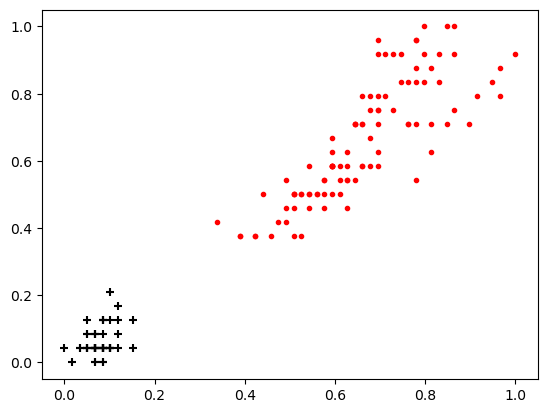

In [15]:
plt.scatter(df1[2], df1[3], color = 'red' , marker ='.')
plt.scatter(df2[2], df2[3], color = 'black' , marker ='+')
plt.show()

In [16]:
df = pd.DataFrame(iris.data)
df


,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [17]:
length = len(df.columns)
length

4

## 📉 Calculate SSE for Different Cluster Counts (Elbow Method)


In [18]:
sse =[]
for i in range(1,length+1):
    km = KMeans(n_clusters=i)
    km.fit(df)
    sse.append(km.inertia_)

print(sse)

[681.3706, 152.34795176035792, 78.8556658259773, 57.38387326549491]


d:\Miniconda\envs\ai-bootcamp\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Miniconda\envs\ai-bootcamp\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Miniconda\envs\ai-bootcamp\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Miniconda\envs\ai-bootcamp\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a m

## 🧠 What is the Elbow Method?

The **Elbow Method** is a popular technique used to determine the **optimal number of clusters (K)** for KMeans clustering.

### 📊 How It Works:
1. **KMeans** is applied to the data for a range of values of K (e.g., 1 to 10).
2. For each K, the **SSE (Sum of Squared Errors)** is computed, which represents the compactness of the clusters.
   - This is also called **inertia_** in scikit-learn's KMeans.
3. A line plot is made:  
   - **X-axis**: number of clusters (K)  
   - **Y-axis**: SSE value for each K

### 🎯 Interpretation:
- As the number of clusters increases, SSE naturally decreases.
- At some point, the **rate of decrease sharply slows down**—forming an “elbow” in the plot.
- The **K at this elbow point** is considered the optimal number of clusters because it balances **model complexity and clustering performance**.

The method helps avoid overfitting while achieving good grouping of the data.


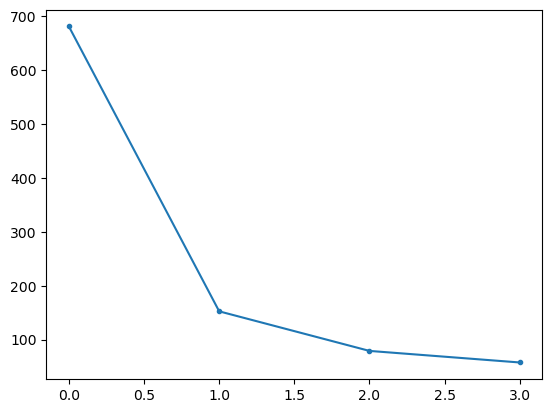

In [19]:
plt.plot(range(length),sse)
plt.scatter(range(length),sse, marker ='.')
plt.show()

##What did you identify from the elbow method? Use elbow method to identify the number of clusters and try applying K-Means on that number of clusters.

In [20]:
#Code here

In [21]:
iris = load_iris()
df = pd.DataFrame(iris.data)
df

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [22]:
# I Use only petal length and width (columns 2 and 3)
df = df[[2, 3]]


In [23]:
#Scale the data
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=['petal_length', 'petal_width'])

In [24]:
# Find optimal k using elbow method
sse = []
for k in range(1, 11):
    km = KMeans(n_clusters=k)
    km.fit(df_scaled)
    sse.append(km.inertia_)

d:\Miniconda\envs\ai-bootcamp\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Miniconda\envs\ai-bootcamp\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Miniconda\envs\ai-bootcamp\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Miniconda\envs\ai-bootcamp\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a m

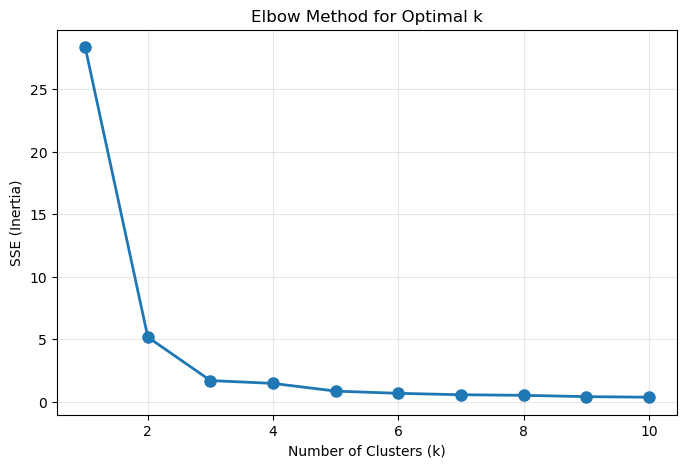

In [25]:
# Plot elbow
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), sse, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
# Step 5: Apply K-Means with k=3
kmeans = KMeans(n_clusters=3)
df_scaled['cluster'] = kmeans.fit_predict(df_scaled)

d:\Miniconda\envs\ai-bootcamp\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


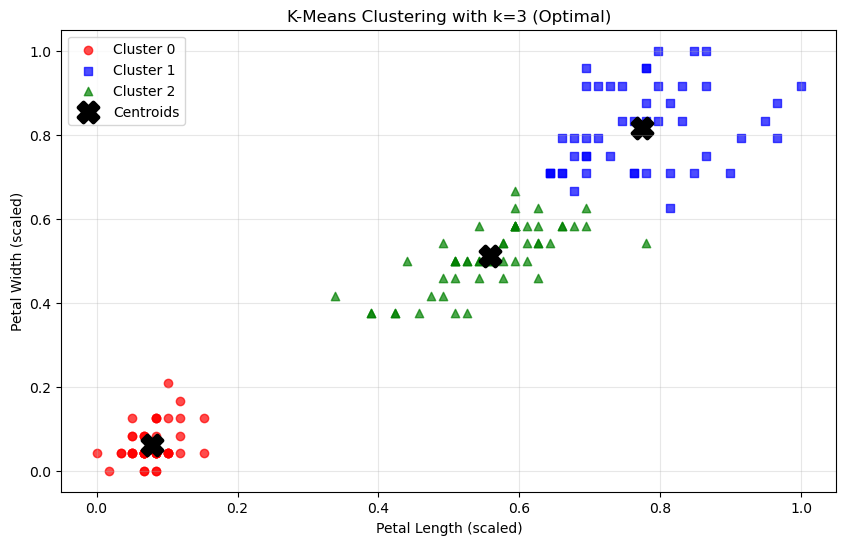

In [27]:
# Visualize the clusters
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green']
markers = ['o', 's', '^']

for i in range(3):
    cluster_data = df_scaled[df_scaled['cluster'] == i]
    plt.scatter(cluster_data['petal_length'], cluster_data['petal_width'], color=colors[i], marker=markers[i], label=f'Cluster {i}', alpha=0.7)
# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], color='black', marker='X', s=200, label='Centroids', linewidths=3)
plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.title('K-Means Clustering with k=3 (Optimal)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
#Print cluster distribution
print("Number of samples in each cluster:")
print(df_scaled['cluster'].value_counts())

Number of samples in each cluster:
cluster
2    52
0    50
1    48
Name: count, dtype: int64


In [29]:
#From the elbow method, I identified that k=3 is the optimal number of clusters because the SSE decreases sharply 
#until k=3, after which the improvement becomes minimal.When applying K-Means with k=3, the data is divided into 
#three distinct clusters that correspond to the three Iris species: Setosa, Versicolor, and Virginica.
#The clusters are well-separated, especially Iris Setosa, which is completely separated from the other two species.